## 2. SVM  (15 points):

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Load the dataset
df = pd.read_csv("mobile_price.csv")

In [2]:
# 2. Separate the dataset into features (X) and target label (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

In [3]:
# 3. Shuffle and split the data into 60% training, 20% validation, and 20% testing
# First, we split the data into a 60% train set and a 40% temporary set.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)

# Second, we split the 40% temporary set equally in half to get 20% validation and 20% test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

In [4]:
# 4. Train the SVM classifier with regularization parameter C=1.0
svm_model = SVC(C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [5]:
# 5. Make predictions on all sets
y_train_pred = svm_model.predict(X_train)
y_val_pred = svm_model.predict(X_val)
y_test_pred = svm_model.predict(X_test)

In [6]:
# 6. Report Accuracy and F1-score for each set
# Note: average='weighted' is used because price_range is a multi-class target (0, 1, 2, 3)
datasets = {
    'Training': (y_train, y_train_pred),
    'Validation': (y_val, y_val_pred),
    'Testing': (y_test, y_test_pred)
}

print("SVM Model Performance (C=1.0):")
print("-" * 35)
for name, (y_true, y_pred) in datasets.items():
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"[{name} Data]")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("-" * 35)

SVM Model Performance (C=1.0):
-----------------------------------
[Training Data]
Accuracy : 0.9450
F1-Score : 0.9445
-----------------------------------
[Validation Data]
Accuracy : 0.9450
F1-Score : 0.9448
-----------------------------------
[Testing Data]
Accuracy : 0.9575
F1-Score : 0.9573
-----------------------------------


In [7]:
import matplotlib.pyplot as plt

# 1. Define the values of C to explore
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# Lists to store the evaluation metrics for each C
train_acc, val_acc, test_acc = [], [], []
train_f1, val_f1, test_f1 = [], [], []

In [8]:
# 2. Iterate through each C value, train the model, and evaluate
for c in C_values:
    # Initialize and train the SVM
    svm_model = SVC(C=c, random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Predict on all three sets
    y_train_pred = svm_model.predict(X_train)
    y_val_pred = svm_model.predict(X_val)
    y_test_pred = svm_model.predict(X_test)
    
    # Calculate and store Accuracy
    train_acc.append(accuracy_score(y_train, y_train_pred))
    val_acc.append(accuracy_score(y_val, y_val_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))
    
    # Calculate and store F1-score (using weighted average for multi-class)
    train_f1.append(f1_score(y_train, y_train_pred, average='weighted'))
    val_f1.append(f1_score(y_val, y_val_pred, average='weighted'))
    test_f1.append(f1_score(y_test, y_test_pred, average='weighted'))

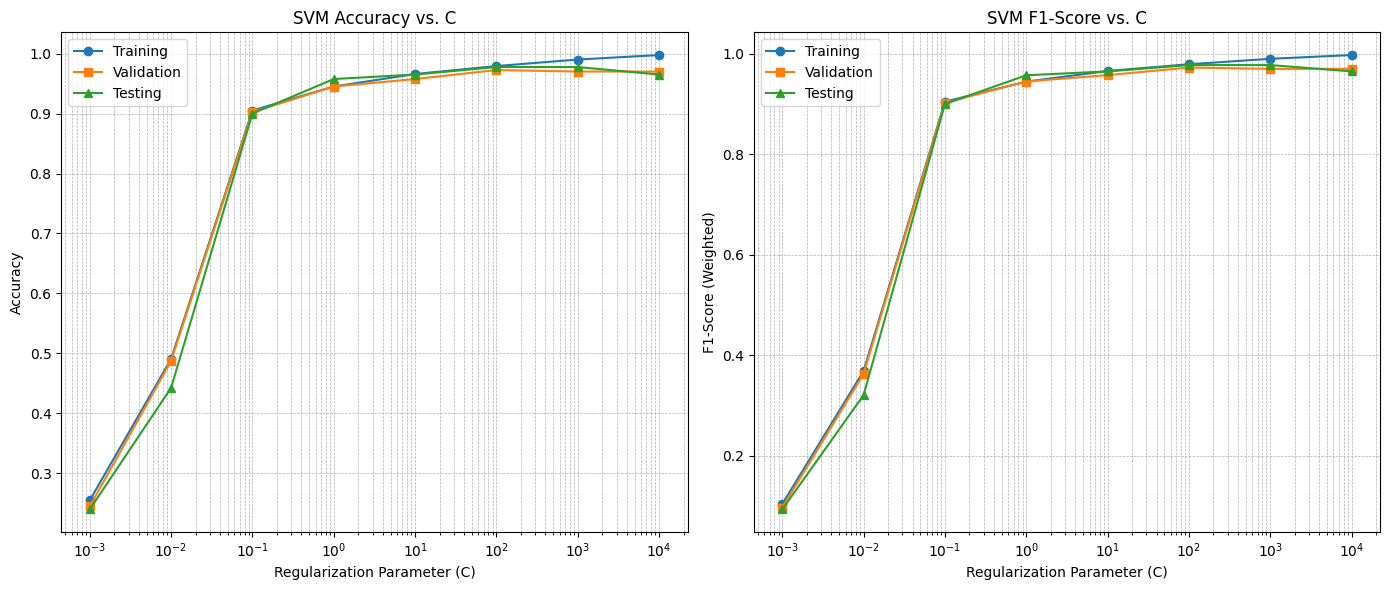

C          | Val Acc    | Test Acc   | Val F1     | Test F1   
------------------------------------------------------------
0.001      | 0.2450     | 0.2400     | 0.0964     | 0.0929    
0.01       | 0.4875     | 0.4425     | 0.3628     | 0.3204    
0.1        | 0.9025     | 0.9000     | 0.9024     | 0.9000    
1          | 0.9450     | 0.9575     | 0.9448     | 0.9573    
10         | 0.9575     | 0.9650     | 0.9575     | 0.9650    
100        | 0.9725     | 0.9775     | 0.9726     | 0.9776    
1000       | 0.9700     | 0.9775     | 0.9700     | 0.9775    
10000      | 0.9700     | 0.9650     | 0.9700     | 0.9650    


In [9]:
# 3. Visualize the results using line plots
plt.figure(figsize=(14, 6))

# Plot 1: Accuracy across different values of C
plt.subplot(1, 2, 1)
plt.plot(C_values, train_acc, marker='o', label='Training')
plt.plot(C_values, val_acc, marker='s', label='Validation')
plt.plot(C_values, test_acc, marker='^', label='Testing')
plt.xscale('log') # Log scale because C varies by powers of 10
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy vs. C')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)

# Plot 2: F1-score across different values of C
plt.subplot(1, 2, 2)
plt.plot(C_values, train_f1, marker='o', label='Training')
plt.plot(C_values, val_f1, marker='s', label='Validation')
plt.plot(C_values, test_f1, marker='^', label='Testing')
plt.xscale('log')
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('F1-Score (Weighted)')
plt.title('SVM F1-Score vs. C')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)

# Display the plots
plt.tight_layout()
plt.show()

# Optional: Print out the raw scores for precise reporting in the assignment
print(f"{'C':<10} | {'Val Acc':<10} | {'Test Acc':<10} | {'Val F1':<10} | {'Test F1':<10}")
print("-" * 60)
for i, c in enumerate(C_values):
    print(f"{c:<10} | {val_acc[i]:<10.4f} | {test_acc[i]:<10.4f} | {val_f1[i]:<10.4f} | {test_f1[i]:<10.4f}")